In [46]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [47]:
df = pd.read_csv("oil and gas.csv")

df.head()

,Production Date,Land Class,Land Category,State,County,FIPS Code,Offshore Region,Commodity,Disposition Code,Disposition Description,Volume
0,01/01/2015,Federal,Offshore,NaN,NaN,NaN,Offshore Alaska,Gas (Mcf),1,Sales-Royalty Due-MEASURED,0
1,01/01/2015,Federal,Offshore,NaN,NaN,NaN,Offshore Gulf,Gas (Mcf),1,Sales-Royalty Due-MEASURED,"14,508,756"
2,01/01/2015,Federal,Offshore,NaN,NaN,NaN,Offshore Pacific,Gas (Mcf),1,Sales-Royalty Due-MEASURED,"1,207,520"
3,01/01/2015,Federal,Offshore,NaN,NaN,NaN,Offshore Gulf,Gas (Mcf),4,Sales-Royalty Due-Not Measured,"487,324"
4,01/01/2015,Federal,Offshore,NaN,NaN,NaN,Offshore Pacific,Gas (Mcf),4,Sales-Royalty Due-Not Measured,"114,808"


In [48]:
df.shape

(470830, 11)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 470830 entries, 0 to 470829
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Production Date          470830 non-null  object 
 1   Land Class               470830 non-null  object 
 2   Land Category            470830 non-null  object 
 3   State                    454200 non-null  object 
 4   County                   454200 non-null  object 
 5   FIPS Code                454200 non-null  float64
 6   Offshore Region          10196 non-null   object 
 7   Commodity                470830 non-null  object 
 8   Disposition Code         470830 non-null  int64  
 9   Disposition Description  470830 non-null  object 
 10  Volume                   470830 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 39.5+ MB


In [50]:
df.describe()

,FIPS Code,Disposition Code
count,454200.000000,470830.000000
mean,33246.875359,18.445779
std,16471.270398,14.210678
min,1003.000000,1.000000
25%,22027.000000,10.000000
50%,35045.000000,17.000000
75%,48225.000000,25.000000
max,56045.000000,69.000000


In [51]:
df.isnull().sum()

Production Date                 0
Land Class                      0
Land Category                   0
State                       16630
County                      16630
FIPS Code                   16630
Offshore Region            460634
Commodity                       0
Disposition Code                0
Disposition Description         0
Volume                          0
dtype: int64

In [52]:
for col in df.columns:
    if df[col].dtypes in ['float64', 'int64']:
        df[col].fillna(df[col].median(), inplace = True)
    else:
        df[col].fillna(df[col].mode()[0], inplace = True)



#Encoding categorical variables

label_encoders = {}
for col in df.select_dtypes(include = ['object']).columns :
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders = le

C:\Users\xxx\AppData\Local\Temp\ipykernel_13832\4243468575.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace = True)
C:\Users\xxx\AppData\Local\Temp\ipykernel_13832\4243468575.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [53]:
# Conversion de la date

df['Production Date'] = pd.to_datetime(df['Production Date'])

In [54]:
# volume total produit

print(df["Volume"].sum())

6633763963


In [55]:
# production par type de ressource

commodity_volume = df.groupby('Commodity')['Volume'].sum()

print(commodity_volume)

Commodity
0    4297421932
1    2336342031
Name: Volume, dtype: int64


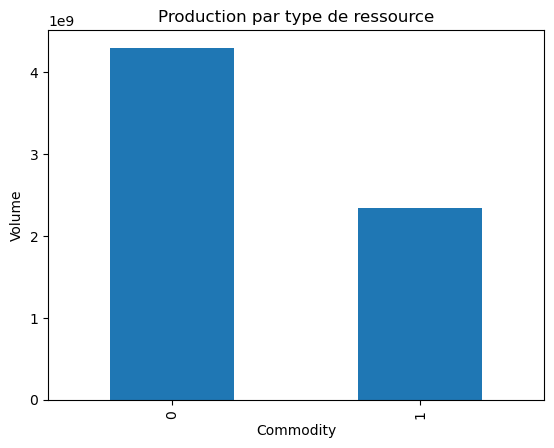

In [56]:
commodity_volume.plot(kind='bar')
plt.title('Production par type de ressource')
plt.ylabel('Volume')
plt.show()

In [61]:
# Etats avec la plus grande production

state_production = df.groupby('State')['Volume'].sum().sort_values(ascending=False)

print(state_production.head(10))

State
26    1231647578
19     686204128
4      657928688
15     565051666
13     513194679
22     457568837
12     442918428
23     359143284
9      281960516
3      249088615
Name: Volume, dtype: int64


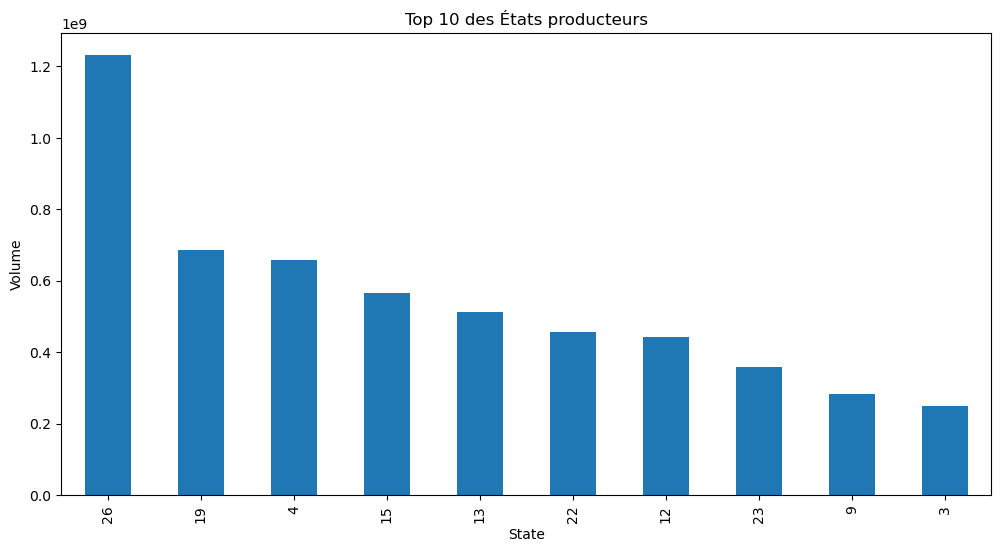

In [62]:
state_production.head(10).plot(kind='bar', figsize=(12,6))

plt.title('Top 10 des États producteurs')
plt.ylabel('Volume')

plt.show()

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [64]:
X = df[['Land Class', 'Land Category', 'State',
        'Offshore Region', 'Commodity']]

y = df['Volume']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size = 0.2, random_state = 42)

In [66]:
model = RandomForestRegressor()

model.fit(X_train,y_train)

RandomForestRegressor()

In [67]:
pred = model.predict(X_test)

In [68]:
mae = mean_absolute_error(y_test,pred)

print("MAE:", mae)

MAE: 10561.791555485193


In [69]:
total_production = df['Volume'].sum()

print("Production Totale :", total_production)

Production Totale : 6633763963


In [70]:
total_states = df['State'].nunique()

print("Nombre d'États :", total_states)

Nombre d'États : 27


In [71]:
top_commodity = df.groupby('Commodity')['Volume'].sum().idxmax()

print("Ressource dominante :", top_commodity)

Ressource dominante : 0


In [72]:
top_region = df.groupby('Offshore Region')['Volume'].sum().idxmax()

print("Région Offshore dominante :", top_region)

Région Offshore dominante : 1


Volumes annuels :
Year
1970    6633763963
Name: Volume, dtype: int64

Croissance annuelle (%) :
Year
1970   NaN
Name: Volume, dtype: float64


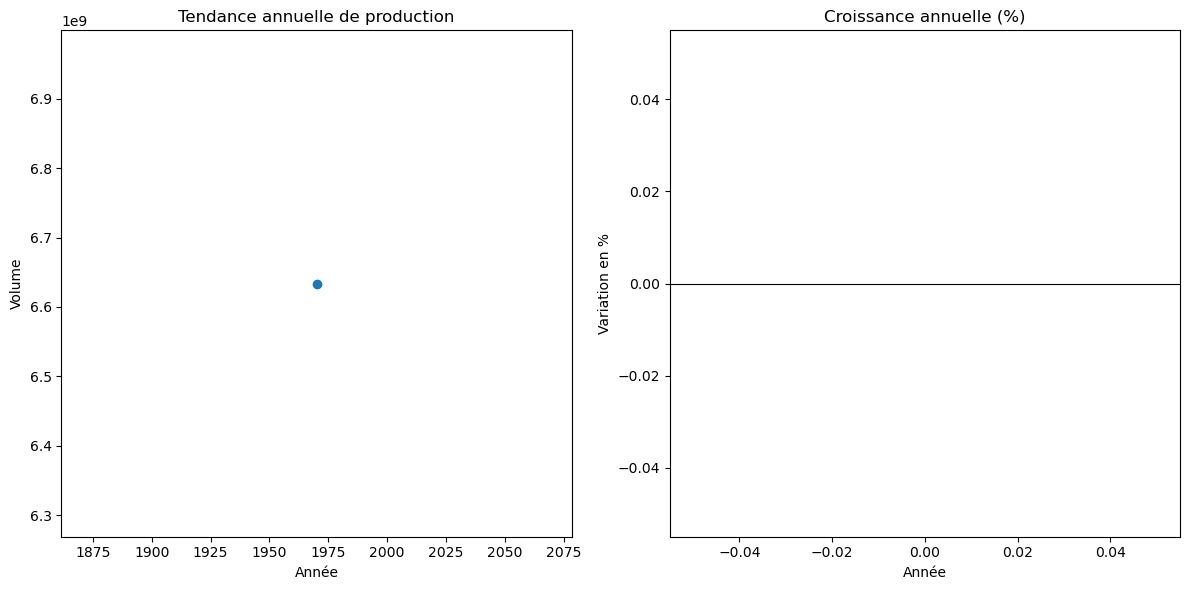

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Conversion correcte des dates
df['Production Date'] = pd.to_datetime(df['Production Date'], errors='coerce')

# 2. Extraire l'année
df['Year'] = df['Production Date'].dt.year

# 3. Agréger par année
yearly_prod = df.groupby('Year')['Volume'].sum()

# 4. Calculer la croissance annuelle en %
growth = yearly_prod.pct_change() * 100

print("Volumes annuels :")
print(yearly_prod)
print("\nCroissance annuelle (%) :")
print(growth)

# 5. Visualiser
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(yearly_prod.index, yearly_prod.values, marker="o")
plt.title("Tendance annuelle de production")
plt.xlabel("Année")
plt.ylabel("Volume")

plt.subplot(1,2,2)
plt.bar(growth.index, growth.values, color="skyblue")
plt.title("Croissance annuelle (%)")
plt.xlabel("Année")
plt.ylabel("Variation en %")
plt.axhline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()


In [93]:
print(df['Production Date'].dt.year.unique())

[1970]


In [94]:
print(df['Production Date'].head(20))

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
5    1970-01-01
6    1970-01-01
7    1970-01-01
8    1970-01-01
9    1970-01-01
10   1970-01-01
11   1970-01-01
12   1970-01-01
13   1970-01-01
14   1970-01-01
15   1970-01-01
16   1970-01-01
17   1970-01-01
18   1970-01-01
19   1970-01-01
Name: Production Date, dtype: datetime64[ns]


In [95]:
df = pd.read_csv("oil and gas.csv", dtype={'production_date': str})

In [96]:
print(df['Production Date'].head(20))


0     01/01/2015
1     01/01/2015
2     01/01/2015
3     01/01/2015
4     01/01/2015
5     01/01/2015
6     01/01/2015
7     01/01/2015
8     01/01/2015
9     01/01/2015
10    01/01/2015
11    01/01/2015
12    01/01/2015
13    01/01/2015
14    01/01/2015
15    01/01/2015
16    01/01/2015
17    01/01/2015
18    01/01/2015
19    01/01/2015
Name: Production Date, dtype: object


In [97]:
df['Production Date'] = pd.to_datetime(df['Production Date'], format="%d/%m/%Y", errors='coerce')

In [98]:
df['Production Date'] = pd.to_datetime(df['Production Date'], format="%m/%d/%Y", errors='coerce')

In [99]:
print(df['Production Date'].dt.year.unique())

[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [101]:
print(df['Volume'].dtype)

object


In [102]:
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

In [104]:
yearly_prod = df.groupby(df['Production Date'].dt.year)['Volume'].sum()

In [105]:
growth = yearly_prod.pct_change() * 100
print(yearly_prod)
print(growth)

Production Date
2015    1638819.0
2016    1604054.0
2017    1535695.0
2018    1506402.0
2019    1463545.0
2020    1473442.0
2021    1461286.0
2022    1410364.0
2023    1437771.0
2024    1392318.0
2025     565959.0
Name: Volume, dtype: float64
Production Date
2015          NaN
2016    -2.121345
2017    -4.261640
2018    -1.907475
2019    -2.844991
2020     0.676235
2021    -0.825007
2022    -3.484739
2023     1.943257
2024    -3.161352
2025   -59.351312
Name: Volume, dtype: float64


In [108]:
# Combiner dans un DataFrame
result = pd.DataFrame({
    "Year": yearly_prod.index,
    "Volume": yearly_prod.values,
    "Growth (%)": growth.values
})

In [109]:
# Sauvegarde en CSV
result.to_csv("production_growth.csv", index=False)

print("✅ Fichier 'production_growth.csv' sauvegardé avec succès !")

✅ Fichier 'production_growth.csv' sauvegardé avec succès !
